# Native frozen-Meta distillation grid

This experiment keeps Meta's released decoder fully frozen, uses its native
512-dimensional post-LSTM representation, pools only the official active
gesture interval with confidence weighting, reproduces Meta's raw-input
preprocessing, and selects prototype/relational weights using Utah validation
only. Same-day test and different-day labels remain untouched until selection.


## 1. Configuration and semantic class mapping

In [1]:
from pathlib import Path
import copy, csv, json, math, pickle, random, sys
from collections import OrderedDict

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.signal import butter, resample_poly, sosfiltfilt
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

REPO_ROOT = Path(r"C:\Users\Micah\utah-neuro\generic_neuromotor_interface")
UTAH_DATA_PATH = REPO_ROOT / "New_Gesture_Trial_Dataset_Labeled (2).pt"
META_SOURCE_DIR = REPO_ROOT / "emg_data"
EXPERIMENT_ROOT = Path(r"C:\Users\Micah\utah-neuro\MATLAB_Jupyter\04_representation_learning")

CLASS_NAMES = ["thumb left", "thumb right", "thumb up", "thumb down", "thumb press"]
# Official repository order: click=4, down=5, in=6, out=7, up=8.
# Assumption for a right hand: Utah left=in and Utah right=out. Reverse the first
# two entries if the Utah task used the opposite hand/orientation.
UTAH_TO_META_IDS = [6, 7, 8, 5, 4]
META_NAMES_BY_UTAH_CLASS = ["thumb_in", "thumb_out", "thumb_up", "thumb_down", "thumb_click"]
META_NAME_TO_CLASS = {name: i for i, name in enumerate(META_NAMES_BY_UTAH_CLASS)}

UTAH_HZ, META_HZ = 30_000, 2_000
UTAH_CHANNELS, META_CHANNELS, WINDOW_SAMPLES = 32, 16, 2_000
BATCH_SIZE = 16
META_BATCH_SIZE = 64
NUM_WORKERS = 0  # HDF5-safe in Jupyter/Windows
EMBED_DIM = 512
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 120
PATIENCE = 25
META_MAX_FILES = None       # None uses all available Meta user files
META_EVENTS_PER_CLASS_PER_FILE = 12
HIGH_PASS_HZ = 40.0

assert UTAH_DATA_PATH.exists(), UTAH_DATA_PATH
assert META_SOURCE_DIR.exists(), META_SOURCE_DIR
assert len(set(UTAH_TO_META_IDS)) == 5
print("Device:", DEVICE)
print("Utah data:", UTAH_DATA_PATH)
print("Meta source:", META_SOURCE_DIR)
print("Semantic mapping:", dict(zip(CLASS_NAMES, META_NAMES_BY_UTAH_CLASS)))


Device: cpu
Utah data: C:\Users\Micah\utah-neuro\generic_neuromotor_interface\New_Gesture_Trial_Dataset_Labeled (2).pt
Meta source: C:\Users\Micah\utah-neuro\generic_neuromotor_interface\emg_data
Semantic mapping: {'thumb left': 'thumb_in', 'thumb right': 'thumb_out', 'thumb up': 'thumb_up', 'thumb down': 'thumb_down', 'thumb press': 'thumb_click'}


## 2. Utah trial windows and labelled Meta event windows

In [2]:
UTAH_HP = butter(4, HIGH_PASS_HZ, btype="highpass", fs=META_HZ, output="sos")

def crop_or_pad_time(x, start, length):
    out = torch.zeros((length,) + tuple(x.shape[1:]), dtype=x.dtype)
    src0, src1 = max(0, start), min(len(x), start + length)
    if src1 > src0:
        out[src0 - start:src1 - start] = x[src0:src1]
    return out

def prepare_utah_trial(trial):
    emg = torch.as_tensor(trial["ns5_vector"]).float()
    if emg.ndim != 2: raise ValueError(f"Bad Utah EMG shape {tuple(emg.shape)}")
    if emg.shape[0] == UTAH_CHANNELS: emg = emg.T
    if emg.shape[1] != UTAH_CHANNELS: raise ValueError(tuple(emg.shape))
    labels = torch.as_tensor(trial["trainKin"]).float()
    if labels.shape[0] != emg.shape[0]: labels = labels.T
    valid = torch.as_tensor(trial.get("valid_mask", torch.ones(len(emg)))).bool().flatten()
    active = (labels[:, :5].amax(1) > .5) & valid[:len(labels)]
    idx = torch.nonzero(active, as_tuple=False).flatten()
    if len(idx) == 0: raise ValueError(f"Trial {trial.get('trial_num')} has no active label")
    center = int(torch.round(idx.float().mean()).item())
    raw = crop_or_pad_time(emg, center - UTAH_HZ // 2, UTAH_HZ).T.numpy()
    x = resample_poly(raw, up=1, down=UTAH_HZ // META_HZ, axis=1)
    x = sosfiltfilt(UTAH_HP, x, axis=1).astype(np.float32)
    if x.shape != (UTAH_CHANNELS, WINDOW_SAMPLES): raise RuntimeError(x.shape)
    scale = np.median(np.abs(x), axis=1, keepdims=True) + 1e-6
    x = np.clip(x / scale, -20, 20).astype(np.float32)
    return torch.from_numpy(x), int(trial["gesture"]), int(trial["trial_num"])

class UtahTrials(Dataset):
    def __init__(self, trials):
        good = []
        for t in trials:
            try: good.append(prepare_utah_trial(t))
            except Exception as e: print("Skipping unusable Utah trial", t.get("trial_num"), e)
        self.items = good
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

def read_pandas_fixed_string_column(group, item_name="name"):
    items = [x.decode() for x in group["block0_items"][()]]
    j = items.index(item_name)
    payload = bytes(group["block0_values"][j])
    return np.asarray(pickle.loads(payload)).reshape(-1).astype(str)

class MetaGestureEvents(Dataset):
    """Labelled one-second event windows, indexed without PyTables."""
    def __init__(self, source_dir, max_files=None, per_class_per_file=12):
        files = sorted(Path(source_dir).glob("*.hdf5"))
        if max_files is not None: files = files[:max_files]
        self.files, self.events = files, []
        rng = np.random.default_rng(SEED)
        for file_i, path in enumerate(files):
            with h5py.File(path, "r") as f:
                names = read_pandas_fixed_string_column(f["prompts"], "name")
                times = np.asarray(f["prompts/block1_values"][:, 0])
                timestamps = f["data"]["time"]
                for name, cls in META_NAME_TO_CLASS.items():
                    candidates = np.flatnonzero(names == name)
                    if len(candidates) > per_class_per_file:
                        candidates = rng.choice(candidates, per_class_per_file, replace=False)
                    for j in candidates:
                        center = int(np.searchsorted(timestamps, times[j]))
                        self.events.append((file_i, center, cls))
        if not self.events: raise RuntimeError("No mapped Meta gesture events found")
        self._handles = OrderedDict()
    def __len__(self): return len(self.events)
    def _handle(self, file_i):
        if file_i not in self._handles:
            self._handles[file_i] = h5py.File(self.files[file_i], "r")
            if len(self._handles) > 16:
                _, old = self._handles.popitem(last=False); old.close()
        return self._handles[file_i]
    def __getitem__(self, i):
        file_i, center, cls = self.events[i]
        d = self._handle(file_i)["data"]
        start, end = center - WINDOW_SAMPLES // 2, center + WINDOW_SAMPLES // 2
        src0, src1 = max(0, start), min(len(d), end)
        x = np.zeros((META_CHANNELS, WINDOW_SAMPLES), np.float32)
        if src1 > src0: x[:, src0-start:src1-start] = np.asarray(d[src0:src1]["emg"], np.float32).T
        # Match Meta's official DiscreteGesturesTransform: the downloaded
        # EMG values are converted directly to float with no per-window scaling.
        return torch.from_numpy(x), int(cls)

saved = torch.load(UTAH_DATA_PATH, map_location="cpu", weights_only=False)
utah_train, utah_val, utah_test = [UtahTrials(saved[k]) for k in ("train", "val", "test")]
meta_events = MetaGestureEvents(META_SOURCE_DIR, META_MAX_FILES, META_EVENTS_PER_CLASS_PER_FILE)

def loader(ds, batch, shuffle):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

utah_train_loader = loader(utah_train, BATCH_SIZE, True)
utah_val_loader = loader(utah_val, BATCH_SIZE, False)
utah_test_loader = loader(utah_test, BATCH_SIZE, False)
meta_loader = loader(meta_events, META_BATCH_SIZE, True)
print("Utah train/val/test:", len(utah_train), len(utah_val), len(utah_test))
print("Meta files/events:", len(meta_events.files), len(meta_events))
print("Utah batch:", next(iter(utah_train_loader))[0].shape)
print("Meta batch:", next(iter(meta_loader))[0].shape)


Utah train/val/test: 80 10 10
Meta files/events: 100 6000
Utah batch: torch.Size([16, 32, 2000])


Meta batch: torch.Size([64, 16, 2000])


## 3. Matched-capacity temporal encoders and evaluation helpers

In [3]:
class ConvStem(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 48, 9, stride=4, padding=4, bias=False), nn.GroupNorm(6,48), nn.SiLU(),
            nn.Conv1d(48, 64, 7, stride=4, padding=3, bias=False), nn.GroupNorm(8,64), nn.SiLU(),
            nn.Conv1d(64, 96, 5, stride=2, padding=2, bias=False), nn.GroupNorm(8,96), nn.SiLU())
    def forward(self, x): return self.net(x)

class SharedTrunk(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(96, 128, 5, stride=2, padding=2, bias=False), nn.GroupNorm(8,128), nn.SiLU(),
            nn.Conv1d(128, 128, 3, padding=1, bias=False), nn.GroupNorm(8,128), nn.SiLU(),
            nn.AdaptiveAvgPool1d(1))
        self.proj = nn.Linear(128, embed_dim)
    def forward(self, x): return F.normalize(self.proj(self.net(x).squeeze(-1)), dim=1)

class SingleDomainClassifier(nn.Module):
    def __init__(self, channels):
        super().__init__(); self.stem=ConvStem(channels); self.trunk=SharedTrunk(); self.head=nn.Linear(EMBED_DIM,5)
    def forward(self,x,return_embedding=False):
        z=self.trunk(self.stem(x)); logits=self.head(z)
        return (logits,z) if return_embedding else logits

def evaluate(model, data_loader, domain=None):
    model.eval(); ys=[]; ps=[]; loss_sum=0.; n=0
    with torch.no_grad():
        for batch in data_loader:
            x,y=batch[0].to(DEVICE),batch[1].to(DEVICE)
            logits=model(x,domain) if domain is not None else model(x)
            loss_sum += F.cross_entropy(logits,y,reduction="sum").item(); n += len(y)
            ys.extend(y.cpu().tolist()); ps.extend(logits.argmax(1).cpu().tolist())
    recalls=[]
    for c in range(5):
        idx=np.array(ys)==c
        if idx.any(): recalls.append(float((np.array(ps)[idx]==c).mean()))
    return {"loss":loss_sum/max(1,n),"acc":float(np.mean(np.array(ys)==np.array(ps))),
            "balanced_acc":float(np.mean(recalls)),"y":ys,"pred":ps}

def save_outputs(out_dir, model, history, result, extra):
    out_dir.mkdir(parents=True,exist_ok=True)
    torch.save({"model_state_dict":model.state_dict(),"class_names":CLASS_NAMES,
                "semantic_mapping":META_NAMES_BY_UTAH_CLASS,"extra":extra},out_dir/"best_model.pt")
    with open(out_dir/"history.json","w") as f: json.dump(history,f,indent=2)
    summary={k:v for k,v in result.items() if k not in ("y","pred")}; summary.update(extra)
    with open(out_dir/"test_metrics.json","w") as f: json.dump(summary,f,indent=2)
    cm=np.zeros((5,5),dtype=int)
    for y,p in zip(result["y"],result["pred"]): cm[y,p]+=1
    np.savetxt(out_dir/"test_confusion_matrix.csv",cm,fmt="%d",delimiter=",")
    fig,axs=plt.subplots(1,3,figsize=(16,4.5))
    axs[0].plot(history["train_loss"],label="train"); axs[0].plot(history["val_loss"],label="val"); axs[0].set(title="Loss",xlabel="epoch"); axs[0].legend()
    axs[1].plot(history["train_acc"],label="train"); axs[1].plot(history["val_acc"],label="val"); axs[1].axhline(.2,ls="--",c="k",alpha=.5); axs[1].set(title="Utah accuracy",xlabel="epoch",ylim=(0,1.05)); axs[1].legend()
    image=axs[2].imshow(cm,cmap="Blues"); axs[2].set_xticks(range(5),["left","right","up","down","press"],rotation=30,ha="right"); axs[2].set_yticks(range(5),["left","right","up","down","press"])
    axs[2].set(xlabel="Predicted",ylabel="True",title="Blind Utah test")
    threshold=cm.max()/2 if cm.size else 0
    for i in range(5):
        for j in range(5): axs[2].text(j,i,str(cm[i,j]),ha="center",va="center",color="white" if cm[i,j]>threshold else "black")
    fig.tight_layout(); fig.savefig(out_dir/"training_and_test.png",dpi=200); fig.savefig(out_dir/"training_and_test.svg")
    plt.show(); print(json.dumps(summary,indent=2)); print("Saved:",out_dir)


## 4. Train, validation-select, freeze, and evaluate

Skipping unusable Utah trial 1 Trial 1 has no active label


Skipping unusable Utah trial 6 Trial 6 has no active label


Skipping unusable Utah trial 10 Trial 10 has no active label


Skipping unusable Utah trial 8 Trial 8 has no active label


Skipping unusable Utah trial 7 Trial 7 has no active label
Separate-day frozen evaluation trials: 48
Building native 512-D targets from Meta's released frozen checkpoint


...

        p0.5_r0.15 epoch 080 | train 1.000 | val 0.800


        p0.5_r0.15 epoch 090 | train 1.000 | val 0.800


        p0.5_r0.15 epoch 100 | train 1.000 | val 0.800


        p0.5_r0.15 epoch 110 | train 1.000 | val 0.800


        p0.5_r0.15 epoch 120 | train 1.000 | val 0.800
Selected using validation only: p0.1_r0.15


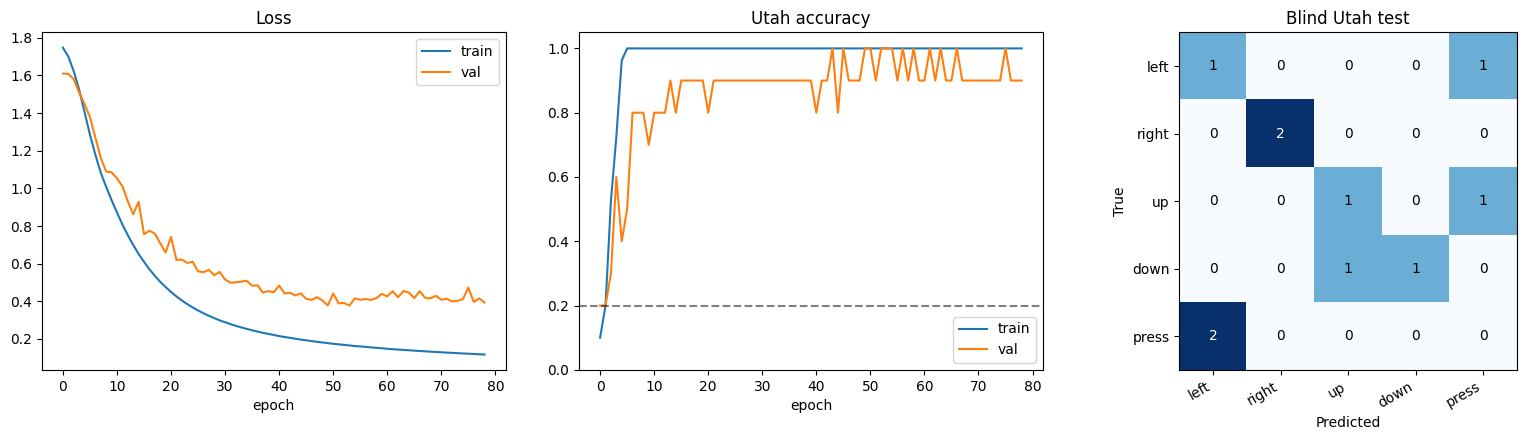

{
  "loss": 1.2401435852050782,
  "acc": 0.5,
  "balanced_acc": 0.5,
  "selection_rule": "prototype and relational weights selected using Utah validation only",
  "teacher_source": "official released frozen checkpoint",
  "teacher_cache": "C:\\Users\\Micah\\utah-neuro\\MATLAB_Jupyter\\04_representation_learning\\official_meta_teacher_cache\\native_512d_confidence_active_targets.pt",
  "teacher_cache_hit": false,
  "teacher_embedding_dim": 512,
  "teacher_pooling": "confidence weighted within official 80-120 ms active interval",
  "meta_preprocessing": "official raw downloaded EMG; no per-window scaling",
  "selected_prototype_weight": 0.1,
  "selected_relational_weight": 0.15,
  "selected_epoch": 54,
  "selected_validation_balanced_accuracy": 1.0,
  "utah_only_same_day_test_accuracy": 0.5,
  "selected_same_day_test_accuracy": 0.5,
  "utah_only_different_day_accuracy": 0.25,
  "selected_different_day_accuracy": 0.25,
  "utah_only_different_day_balanced_accuracy": 0.24,
  "selected_diffe

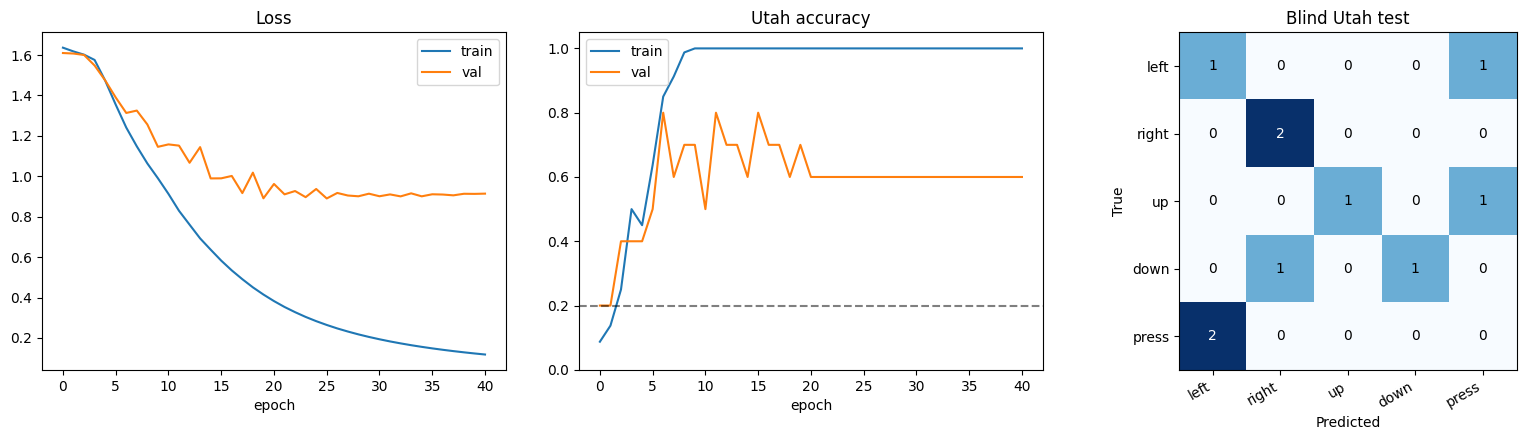

{
  "loss": 1.1696625709533692,
  "acc": 0.5,
  "balanced_acc": 0.5,
  "method": "matched Utah-only",
  "best_epoch": 16,
  "different_day_accuracy": 0.25
}
Saved: C:\Users\Micah\utah-neuro\MATLAB_Jupyter\04_representation_learning\native_frozen_teacher_grid\utah_only


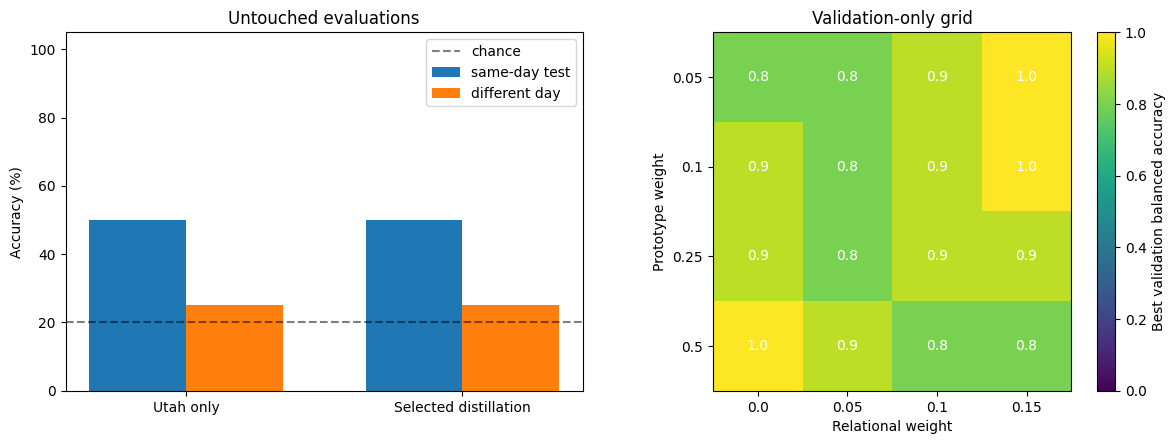

{
  "selection_rule": "prototype and relational weights selected using Utah validation only",
  "teacher_source": "official released frozen checkpoint",
  "teacher_cache": "C:\\Users\\Micah\\utah-neuro\\MATLAB_Jupyter\\04_representation_learning\\official_meta_teacher_cache\\native_512d_confidence_active_targets.pt",
  "teacher_cache_hit": false,
  "teacher_embedding_dim": 512,
  "teacher_pooling": "confidence weighted within official 80-120 ms active interval",
  "meta_preprocessing": "official raw downloaded EMG; no per-window scaling",
  "selected_prototype_weight": 0.1,
  "selected_relational_weight": 0.15,
  "selected_epoch": 54,
  "selected_validation_balanced_accuracy": 1.0,
  "utah_only_same_day_test_accuracy": 0.5,
  "selected_same_day_test_accuracy": 0.5,
  "utah_only_different_day_accuracy": 0.25,
  "selected_different_day_accuracy": 0.25,
  "utah_only_different_day_balanced_accuracy": 0.24,
  "selected_different_day_balanced_accuracy": 0.2533333333333333,
  "different_day_u

In [4]:
OUT_DIR = EXPERIMENT_ROOT / "results" / "native_frozen_teacher"
CROSS_DAY_PATH = REPO_ROOT / "Gesture_Trial_Dataset_Labeled.pt"
PROTO_WEIGHTS = [0.05, 0.10, 0.25, 0.50]
RELATION_WEIGHTS = [0.00, 0.05, 0.10, 0.15]

assert EMBED_DIM == 512
assert CROSS_DAY_PATH.exists(), CROSS_DAY_PATH
cross_saved = torch.load(CROSS_DAY_PATH, map_location="cpu", weights_only=False)
cross_day = UtahTrials(cross_saved["all_trials"])
cross_day_loader = loader(cross_day, BATCH_SIZE, False)
print("Separate-day frozen evaluation trials:", len(cross_day))

def deterministic_loader(ds, batch, shuffle, seed):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=NUM_WORKERS,
                      pin_memory=torch.cuda.is_available(), generator=generator)

if str(EXPERIMENT_ROOT) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_ROOT))
from frozen_meta_teacher_native import load_or_build_native_teacher_targets

teacher_prototypes, teacher_geometry, proto_n, teacher_info = load_or_build_native_teacher_targets(
    repo_root=REPO_ROOT,
    experiment_root=EXPERIMENT_ROOT,
    meta_dataset=meta_events,
    meta_batch_size=META_BATCH_SIZE,
    class_names=META_NAMES_BY_UTAH_CLASS,
    meta_output_ids=UTAH_TO_META_IDS,
    seed=SEED,
    device=DEVICE,
    num_workers=NUM_WORKERS,
)
assert teacher_prototypes.shape == (5, 512)

# Every candidate starts from identical student weights and sees identical batches.
torch.manual_seed(SEED + 1000)
initial_student = SingleDomainClassifier(UTAH_CHANNELS)
initial_student_state = copy.deepcopy(initial_student.state_dict())

def train_candidate(prototype_weight, relational_weight, label):
    random.seed(SEED + 2000); np.random.seed(SEED + 2000); torch.manual_seed(SEED + 2000)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED + 2000)
    train_loader_arm = deterministic_loader(utah_train, BATCH_SIZE, True, SEED + 3000)
    model = SingleDomainClassifier(UTAH_CHANNELS).to(DEVICE)
    model.load_state_dict(initial_student_state)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history = {k: [] for k in ("train_loss","val_loss","train_acc","val_acc","ce","prototype","relational")}
    best_state = None; best_epoch = 0; best_score = (-1.0, float("-inf")); stale = 0

    for epoch in range(1, EPOCHS + 1):
        model.train(); sums = np.zeros(4); correct = count = 0
        for x, y, _ in train_loader_arm:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits, z = model(x, True)
            ce = F.cross_entropy(logits, y)
            proto = (1 - (z * teacher_prototypes[y]).sum(1)).mean()
            present = torch.unique(y)
            centers = torch.stack([F.normalize(z[y == c].mean(0), dim=0) for c in present])
            relational = (
                F.smooth_l1_loss(torch.cdist(centers, centers), teacher_geometry[present][:, present])
                if len(present) > 1 else z.sum() * 0
            )
            loss = ce + prototype_weight * proto + relational_weight * relational
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
            sums += [loss.item()*len(y), ce.item()*len(y), proto.item()*len(y), relational.item()*len(y)]
            correct += (logits.argmax(1) == y).sum().item(); count += len(y)

        val = evaluate(model, utah_val_loader)
        history["train_loss"].append(sums[0]/count); history["val_loss"].append(val["loss"])
        history["train_acc"].append(correct/count); history["val_acc"].append(val["acc"])
        history["ce"].append(sums[1]/count); history["prototype"].append(sums[2]/count)
        history["relational"].append(sums[3]/count)
        score = (val["balanced_acc"], -val["loss"])
        if score > best_score:
            best_score = score; best_state = copy.deepcopy(model.state_dict()); best_epoch = epoch; stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0:
            print(f"{label:>18} epoch {epoch:03d} | train {correct/count:.3f} | val {val['acc']:.3f}")
        if stale >= PATIENCE:
            break

    return {
        "label": label,
        "prototype_weight": float(prototype_weight),
        "relational_weight": float(relational_weight),
        "best_epoch": int(best_epoch),
        "best_val_balanced_accuracy": float(best_score[0]),
        "best_val_loss": float(-best_score[1]),
        "state": best_state,
        "history": history,
    }

# Baseline is not part of hyperparameter selection.
baseline = train_candidate(0.0, 0.0, "utah_only")

# Grid selection uses only the same-day Utah validation split.
grid_results = []
for prototype_weight in PROTO_WEIGHTS:
    for relational_weight in RELATION_WEIGHTS:
        label = f"p{prototype_weight:g}_r{relational_weight:g}"
        grid_results.append(train_candidate(prototype_weight, relational_weight, label))

selected = max(
    grid_results,
    key=lambda result: (
        result["best_val_balanced_accuracy"],
        -result["best_val_loss"],
        -result["best_epoch"],
    ),
)
print("Selected using validation only:", selected["label"])

def restore_and_score(result):
    model = SingleDomainClassifier(UTAH_CHANNELS).to(DEVICE)
    model.load_state_dict(result["state"])
    return model, evaluate(model, utah_test_loader), evaluate(model, cross_day_loader)

# Test and different-day labels are first accessed only after grid selection.
baseline_model, baseline_same, baseline_cross = restore_and_score(baseline)
selected_model, selected_same, selected_cross = restore_and_score(selected)

OUT_DIR.mkdir(parents=True, exist_ok=True)
grid_rows = [
    {key: value for key, value in result.items() if key not in ("state", "history")}
    for result in grid_results
]
with (OUT_DIR / "validation_grid.json").open("w") as f: json.dump(grid_rows, f, indent=2)
with (OUT_DIR / "validation_grid.csv").open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(grid_rows[0])); writer.writeheader(); writer.writerows(grid_rows)

summary = {
    "selection_rule": "prototype and relational weights selected using Utah validation only",
    "teacher_source": "official released frozen checkpoint",
    "teacher_cache": teacher_info["cache_path"],
    "teacher_cache_hit": teacher_info["cache_hit"],
    "teacher_embedding_dim": 512,
    "teacher_pooling": "confidence weighted within official 80-120 ms active interval",
    "meta_preprocessing": "official raw downloaded EMG; no per-window scaling",
    "selected_prototype_weight": selected["prototype_weight"],
    "selected_relational_weight": selected["relational_weight"],
    "selected_epoch": selected["best_epoch"],
    "selected_validation_balanced_accuracy": selected["best_val_balanced_accuracy"],
    "utah_only_same_day_test_accuracy": baseline_same["acc"],
    "selected_same_day_test_accuracy": selected_same["acc"],
    "utah_only_different_day_accuracy": baseline_cross["acc"],
    "selected_different_day_accuracy": selected_cross["acc"],
    "utah_only_different_day_balanced_accuracy": baseline_cross["balanced_acc"],
    "selected_different_day_balanced_accuracy": selected_cross["balanced_acc"],
    "different_day_usable_trials": len(cross_day),
}
with (OUT_DIR / "final_summary.json").open("w") as f: json.dump(summary, f, indent=2)

save_outputs(
    OUT_DIR / "selected_distillation", selected_model, selected["history"], selected_same,
    {**summary, "method": "native frozen Meta distillation"},
)
save_outputs(
    OUT_DIR / "utah_only", baseline_model, baseline["history"], baseline_same,
    {"method": "matched Utah-only", "best_epoch": baseline["best_epoch"],
     "different_day_accuracy": baseline_cross["acc"]},
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
matrix = np.array([
    [100*baseline_same["acc"], 100*baseline_cross["acc"]],
    [100*selected_same["acc"], 100*selected_cross["acc"]],
])
x = np.arange(2); width = 0.35
axes[0].bar(x-width/2, matrix[:,0], width, label="same-day test")
axes[0].bar(x+width/2, matrix[:,1], width, label="different day")
axes[0].axhline(20, ls="--", c="k", alpha=.5, label="chance")
axes[0].set_xticks(x, ["Utah only", "Selected distillation"])
axes[0].set(ylabel="Accuracy (%)", ylim=(0,105), title="Untouched evaluations"); axes[0].legend()

grid_matrix = np.zeros((len(PROTO_WEIGHTS), len(RELATION_WEIGHTS)))
for result in grid_results:
    i = PROTO_WEIGHTS.index(result["prototype_weight"])
    j = RELATION_WEIGHTS.index(result["relational_weight"])
    grid_matrix[i,j] = result["best_val_balanced_accuracy"]
image = axes[1].imshow(grid_matrix, vmin=0, vmax=1, cmap="viridis")
axes[1].set_xticks(range(len(RELATION_WEIGHTS)), RELATION_WEIGHTS)
axes[1].set_yticks(range(len(PROTO_WEIGHTS)), PROTO_WEIGHTS)
axes[1].set(xlabel="Relational weight", ylabel="Prototype weight", title="Validation-only grid")
for i in range(len(PROTO_WEIGHTS)):
    for j in range(len(RELATION_WEIGHTS)):
        axes[1].text(j, i, f"{grid_matrix[i,j]:.1f}", ha="center", va="center", color="white")
fig.colorbar(image, ax=axes[1], label="Best validation balanced accuracy")
fig.tight_layout(); fig.savefig(OUT_DIR/"native_teacher_grid_comparison.png", dpi=220); fig.savefig(OUT_DIR/"native_teacher_grid_comparison.svg")
plt.show(); print(json.dumps(summary, indent=2)); print("Saved:", OUT_DIR)
